In [23]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
# Only get data analyst jobs 
#df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

# Drop NaN values from the column for plotting
df_da_us = df_da_us.dropna(subset=['salary_year_avg'])

In [5]:
df_da_us.salary_year_avg.sample(10)

191728     87500.000000
688051     59009.601562
643467    115000.000000
648212     95500.000000
130666    100000.000000
271393    124500.000000
50057     111175.000000
19574      55000.000000
424834    100000.000000
364008     45000.000000
Name: salary_year_avg, dtype: float64

<Axes: >

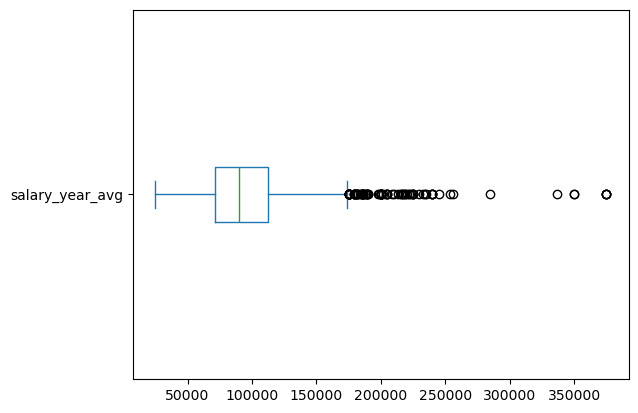

In [13]:
df_da_us.salary_year_avg.plot(kind="box", vert= False)

C:\Users\moham\AppData\Local\Temp\ipykernel_18908\2361872101.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert= False)


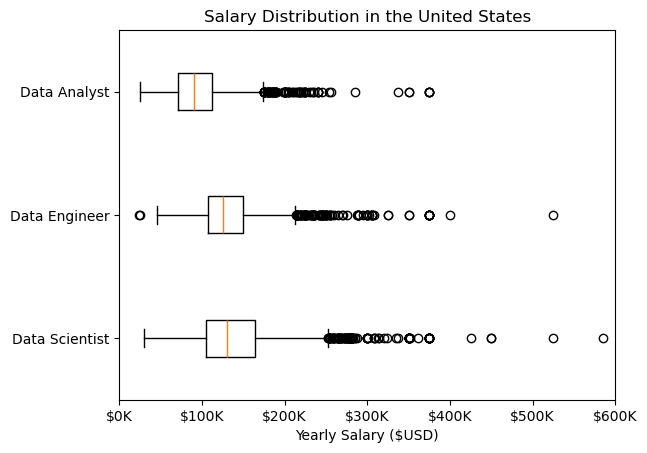

In [27]:
job_titles = ["Data Scientist", "Data Engineer", "Data Analyst"]

df_us = df[(df.job_title_short.isin(job_titles))&(df.job_country == "United States")].copy()
df_us = df_us.dropna(subset='salary_year_avg')

job_list = [df_us[df_us.job_title_short == job_title]["salary_year_avg"] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert= False)

plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
plt.xlim(0, 600000) 
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

In [17]:
df_us.job_title_short.value_counts()

job_title_short
Data Analyst      67816
Data Scientist    58830
Data Engineer     35080
Name: count, dtype: int64